# Customer Churn Prediction Model

## Objective

The objective of this project is to build a machine-learning model capable of predicting whether a customer is likely to churn within the next 60 days.

The model is intended to help the company:

* identify high-risk customers early,
* prioritize retention campaigns,
* reduce customer attrition,
* improve customer lifetime value.

The analysis uses behavioural, transactional, engagement, and support-interaction data available on or before the customer snapshot date.

Strict leakage prevention practices were followed to ensure that future information was not used during model training.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [3]:
rfm = pd.read_csv("/content/rfm_modeling_snapshot.csv")

rfm.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


# Leakage Prevention Strategy

To prevent target leakage, only variables available on or before the customer snapshot date were used as model inputs.

The provided modeling snapshot dataset already contains time-windowed behavioural features such as:

* recency,
* purchase frequency,
* engagement metrics,
* support activity,
* campaign interactions.

The target variable:

* `churn_next_60d`

represents future churn behaviour after the snapshot date and was excluded from feature generation.

No future customer activity, post-churn behaviour, or post-snapshot interventions were used during model training.

The provided `split` column was used to preserve temporal and dataset separation integrity.


In [4]:
train_df = rfm[rfm['split'] == 'train']
val_df = rfm[rfm['split'] == 'validation']
test_df = rfm[rfm['split'] == 'test']

In [5]:
target = 'churn_next_60d'

drop_cols = [
    'customer_id',
    'snapshot_date',
    'split',
    target
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target]

In [6]:
categorical_cols = X_train.select_dtypes(include='object').columns

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col])

    X_val[col] = le.transform(X_val[col])

    X_test[col] = le.transform(X_test[col])

    encoders[col] = le

## Baseline Model: Logistic Regression

Logistic Regression was selected as the baseline model because:

* it is simple and interpretable,
* performs well on binary classification tasks,
* provides a strong benchmark for comparison with more advanced ensemble models.


In [9]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Advanced Model: Random Forest

Random Forest was selected because:

* it captures nonlinear relationships,
* handles mixed feature types effectively,
* is robust to noise and outliers,
* provides feature-importance interpretability.


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:,1]

In [10]:
def evaluate_model(y_true, preds, probs):

    print("Accuracy:", accuracy_score(y_true, preds))
    print("Precision:", precision_score(y_true, preds))
    print("Recall:", recall_score(y_true, preds))
    print("F1 Score:", f1_score(y_true, preds))
    print("ROC AUC:", roc_auc_score(y_true, probs))

In [11]:
print("Logistic Regression Performance")

evaluate_model(
    y_test,
    baseline_preds,
    baseline_probs
)

Logistic Regression Performance
Accuracy: 0.8184523809523809
Precision: 0.8322981366459627
Recall: 0.7976190476190477
F1 Score: 0.8145896656534954
ROC AUC: 0.8861252834467119


In [12]:
print("Random Forest Performance")

evaluate_model(
    y_test,
    rf_preds,
    rf_probs
)

Random Forest Performance
Accuracy: 0.8065476190476191
Precision: 0.8280254777070064
Recall: 0.7738095238095238
F1 Score: 0.8
ROC AUC: 0.8800311791383221


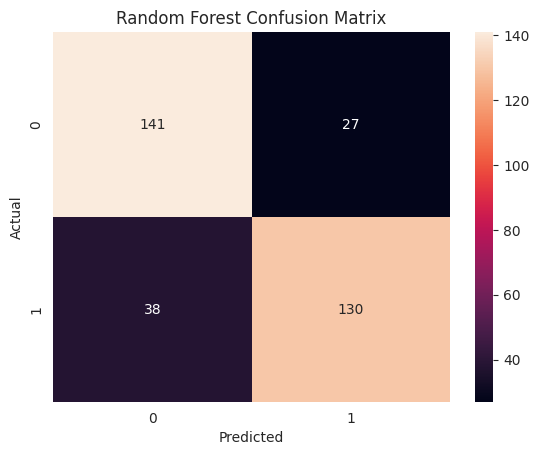

In [13]:
cm = confusion_matrix(y_test, rf_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
custom_threshold = 0.40

custom_preds = (
    rf_probs >= custom_threshold
).astype(int)

evaluate_model(
    y_test,
    custom_preds,
    rf_probs
)

Accuracy: 0.8095238095238095
Precision: 0.7795698924731183
Recall: 0.8630952380952381
F1 Score: 0.8192090395480226
ROC AUC: 0.8800311791383221


# Threshold Selection Strategy

The default classification threshold of 0.50 may not be optimal for churn prediction because missing a true churn-risk customer can be more expensive than incorrectly targeting a retained customer.

A threshold of 0.40 was selected to improve recall and identify more potential churn-risk customers.

Business rationale:

* false negatives represent missed retention opportunities,
* retaining an existing customer is generally cheaper than acquiring a new customer,
* the business prefers broader retention targeting over missing high-risk customers.

The threshold may be adjusted later based on:

* campaign budget,
* retention-team capacity,
* customer lifetime value.


In [15]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(by='importance', ascending=False)
)

feature_importance.head(10)

,feature,importance
6,recency_days,0.306230
24,last_visit_days_ago,0.164167
8,monetary_180d,0.084935
7,frequency_180d,0.051743
10,avg_discount_pct_180d,0.045755
16,days_since_signup,0.043002
18,product_views_30d,0.041375
17,sessions_30d,0.038361
12,category_diversity_180d,0.033022
11,avg_rating_180d,0.020807


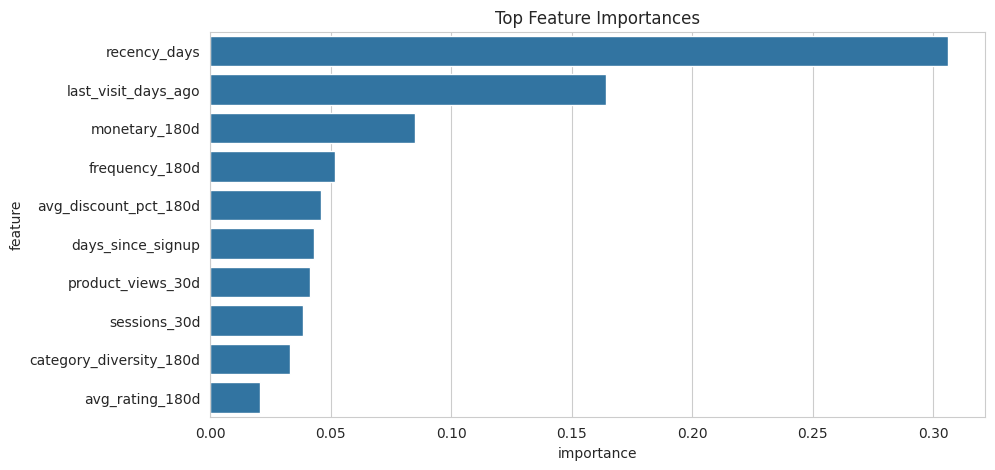

In [16]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_features,
    x='importance',
    y='feature'
)

plt.title("Top Feature Importances")

plt.show()

In [17]:
results = test_df.copy()

results['prediction'] = custom_preds
results['probability'] = rf_probs

In [18]:
false_positives = results[
    (results['churn_next_60d'] == 0) &
    (results['prediction'] == 1)
]

false_positives.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,prediction,probability
43,CUST00044,2025-09-30,Tier 2,35-44,Google Search,NaN,Baby Care,Yes,72,1,899.51,0.0,0.290,4.0,1,0,0.0,0.0,476,6,27,2,1,1,4,2,10,0,test,1,0.463735
108,CUST00109,2025-09-30,Tier 1,25-34,Instagram,Silver,Skin Care,Yes,92,2,1622.28,0.0,0.255,4.5,2,0,0.0,0.0,492,1,4,0,0,0,3,1,16,0,test,1,0.588942
334,CUST00335,2025-09-30,Tier 2,45+,Instagram,NaN,Skin Care,Yes,148,2,1328.14,0.0,0.380,3.5,1,0,0.0,0.0,517,7,40,1,1,0,3,1,22,0,test,1,0.685848
436,CUST00437,2025-09-30,Tier 2,35-44,Marketplace,Silver,Baby Care,Yes,151,1,729.22,0.0,0.250,4.0,1,0,0.0,0.0,216,0,0,0,0,0,0,0,33,0,test,1,0.893266
490,CUST00491,2025-09-30,Tier 1,25-34,Organic,Silver,Makeup,Yes,97,1,540.89,1.0,0.240,4.0,1,1,0.0,31.8,182,10,40,3,2,1,5,1,20,0,test,1,0.714244


In [19]:
false_negatives = results[
    (results['churn_next_60d'] == 1) &
    (results['prediction'] == 0)
]

false_negatives.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split,prediction,probability
183,CUST00184,2025-09-30,Tier 1,18-24,Instagram,Platinum,Wellness,No,14,3,2456.91,0.0,0.287,3.33,2,0,0.0,0.00,564,6,18,1,1,0,0,0,6,1,test,0,0.036102
246,CUST00247,2025-09-30,Tier 2,25-34,Marketplace,NaN,Hair Care,Yes,57,2,937.32,0.0,0.500,3.00,1,0,0.0,0.00,470,5,13,1,0,1,5,2,14,1,test,0,0.331014
378,CUST00379,2025-09-30,Tier 1,45+,Marketplace,NaN,Hair Care,No,75,1,538.25,0.0,0.110,4.00,1,0,0.0,0.00,348,2,11,1,0,1,0,0,4,1,test,0,0.393957
413,CUST00414,2025-09-30,Tier 2,25-34,Marketplace,NaN,Baby Care,Yes,3,1,311.44,1.0,0.320,4.00,1,1,1.0,28.00,33,5,30,3,1,2,6,1,0,1,test,0,0.341142
437,CUST00438,2025-09-30,Tier 1,25-34,Marketplace,Platinum,Baby Care,Yes,64,3,2466.39,1.0,0.160,3.00,3,2,1.0,36.05,175,6,22,1,1,1,7,2,22,1,test,0,0.278613


# Error Analysis

## False Positives

False positives represent customers predicted to churn who ultimately remained active.

Potential causes:

* temporary engagement decline,
* seasonal purchasing behaviour,
* delayed purchasing cycles,
* conservative threshold selection.

Business Impact:

* unnecessary retention spending,
* excess promotional targeting.

However, false positives are generally less harmful than false negatives in churn-retention systems.

---

## False Negatives

False negatives represent customers who churned but were not identified by the model.

Potential causes:

* sudden behavioural changes,
* unobserved external factors,
* operational issues not captured in data.

Business Impact:

* missed retention opportunities,
* revenue loss,
* customer attrition.

Reducing false negatives is especially important for high-value customers.


In [20]:
results[[
    'customer_id',
    'probability',
    'prediction',
    'churn_next_60d',
    'monetary_180d',
    'frequency_180d',
    'ticket_count_90d',
    'sessions_30d'
]].head(10)

,customer_id,probability,prediction,churn_next_60d,monetary_180d,frequency_180d,ticket_count_90d,sessions_30d
15,CUST00016,0.925200,1,1,0.00,0,0,2
17,CUST00018,0.865484,1,1,329.21,1,0,3
23,CUST00024,0.068472,0,0,481.35,1,0,13
24,CUST00025,0.721886,1,1,517.97,1,0,11
29,CUST00030,0.052126,0,0,2819.98,5,2,11
31,CUST00032,0.269579,0,0,694.18,1,0,12
42,CUST00043,0.271109,0,0,363.01,1,0,3
43,CUST00044,0.463735,1,0,899.51,1,0,6
57,CUST00058,0.383018,0,0,644.61,1,0,2
58,CUST00059,0.131244,0,0,1447.55,2,0,3


In [21]:
results.to_csv(
    "predictions.csv",
    index=False
)

In [22]:
import joblib
joblib.dump(
    rf_model,
    'model.pkl'
)

['model.pkl']

In [25]:
import json
metrics = {
    "accuracy": float(
        accuracy_score(y_test, custom_preds)
    ),

    "precision": float(
        precision_score(y_test, custom_preds)
    ),

    "recall": float(
        recall_score(y_test, custom_preds)
    ),

    "f1_score": float(
        f1_score(y_test, custom_preds)
    ),

    "roc_auc": float(
        roc_auc_score(y_test, rf_probs)
    )
}

In [26]:
with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

In [27]:
feature_importance.to_csv(
    'feature_importance.csv',
    index=False
)

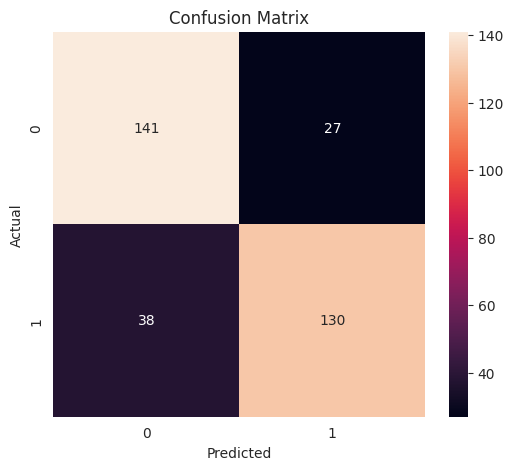

In [28]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    'confusion_matrix.png',
    bbox_inches='tight'
)

plt.show()

In [29]:
from google.colab import files

files.download('model.pkl')
files.download('metrics.json')
files.download('predictions.csv')
files.download('feature_importance.csv')
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>